In [2]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson
import scipy.stats as stats

In [3]:
sim = Simulation("PhotonNoise")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# Single-pixel exposures

numExposures = 1000
sim["ObservingParameters/NumExposures"] = numExposures
sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable natural vignetting

sim["CCD/IncludePhotonNoise"] = "yes"

output = sim.run(removeOutputFile = True)


2020-01-23 10:32:48 WARNING Simulation: no information about detected stars to write to HDF5
2020-01-23 10:32:49 WARNING Camera: No star positions to write to HDF5 file.



In [4]:
# The only contribution comes from the sky background during exposure

exposureTime = output.getInputParameter("ObservingParameters", "CycleTime") - sim.getReadoutTime()[0]

expectedSkyBackground = output.getInputParameter("Sky", "SkyBackground") * exposureTime * output.getInputParameter("Telescope/TransmissionEfficiency", "BOL")

# Flux

In [5]:
flux = np.array([])

for exposure in range(numExposures):
    
    flux = np.append(flux, output.getImage(exposure)[0][0])

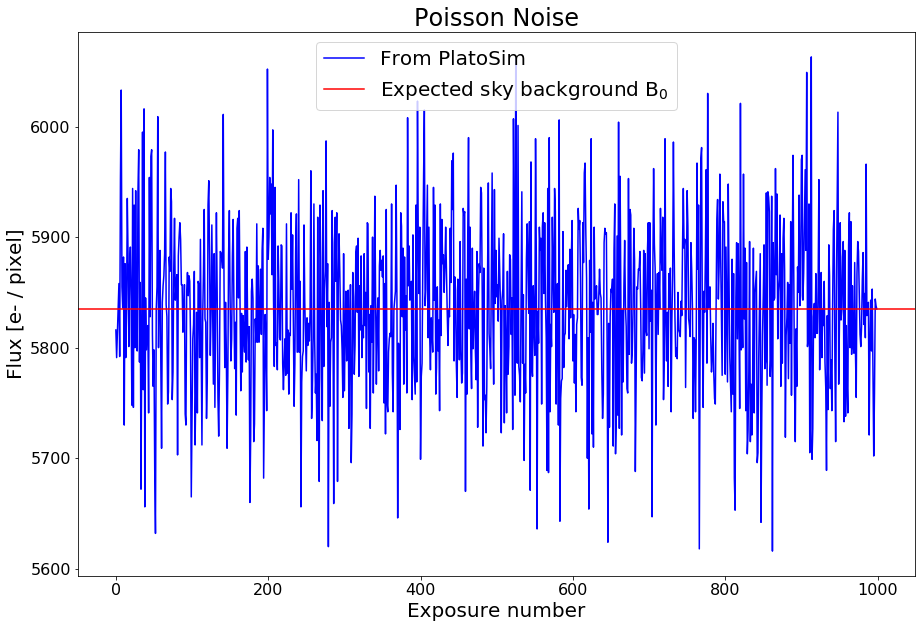

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(flux, "b", label = "From PlatoSim")



#########
# Average
#########

plt.axhline(y = expectedSkyBackground, color = "r", label = "Expected sky background B$_0$")



########
# Layout
########

plt.title("Poisson Noise", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Flux [e- / pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

(5610.177015858, 6060.177015858)

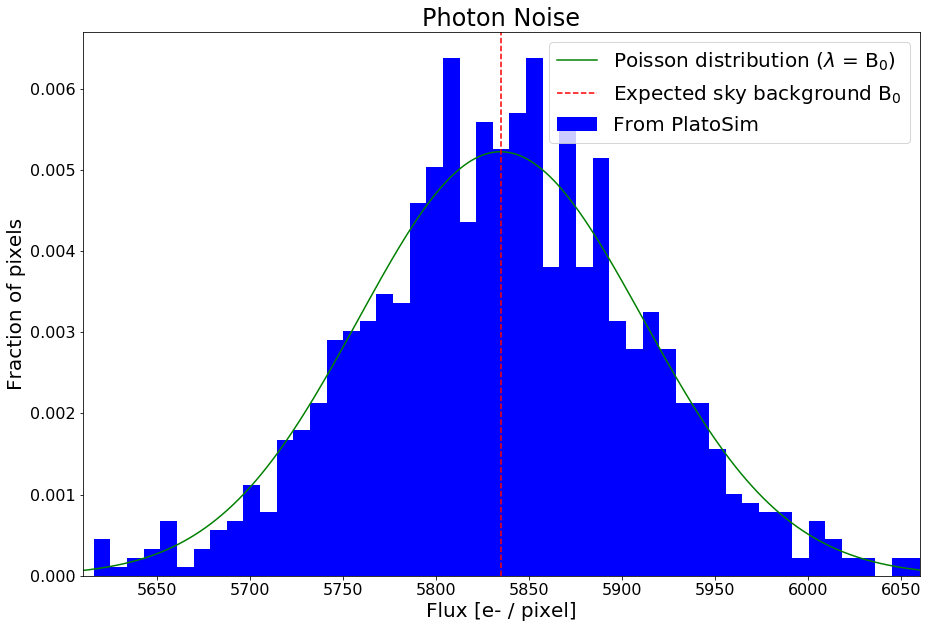

In [7]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

plt.hist(flux, 50, density = True, color = "b", label = "From PlatoSim")



######################
# Poisson distribution
######################

mu = expectedSkyBackground
x =  np.arange(poisson.ppf(0.001, mu),  poisson.ppf(0.999, mu))
ax.plot(x, poisson.pmf(x, mu), "g", label='Poisson distribution ($\\lambda$ = B$_0$)')

plt.axvline(x = mu, color = "r", linestyle = "dashed", label = "Expected sky background B$_0$")


########
# Layout
########

plt.title("Photon Noise", fontsize = 24)
plt.xlabel("Flux [e- / pixel]", fontsize = 20)
plt.ylabel("Fraction of pixels", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([expectedSkyBackground - 225, expectedSkyBackground + 225])